# 4D-STEM DPC disk tracking -- edge cross-correlation method

## by Dan Durham (2023) with updates by Pravan Chakravarthy (2026)

This code uses the edge cross-correlation method (similar to an "elliptical Hough transform") to detect disk shifts from 4D-STEM DPC data. Retrieving phase gradients by this method has reduced sensitivity to dynamical scattering artifacts, but assumes the phase gradients are in the "rigid disk shift" limit, i.e. the phase gradient is uniform across the real-space probe size.

Associated package `dpc4dstem` must be installed (or available as a sub-directory in the same folder as this notebook). Other dependencies include: `matplotlib`, `numpy`, `scipy`, `ncempy`

This code also uses ellipse coordinate functions from a legacy verison of `py4DSTEM` (0.13.7) but this currently does not need to be installed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import matplotlib.animation as animation

from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize

import ncempy.io as nio 

import dpc4dstem as dpc4d

%matplotlib inline

In [2]:
plt.style.use('seaborn-v0_8-poster')

## Prepare 4D data

In [22]:
# Set the filename to read
ftag= "disk_velox"
sample_shape = '_'+ftag[:4]
filepath_input = 'input/' + ftag + ".mrc"

if sample_shape == '_disk':
    R_Ny = 128
    R_Nx = 128
elif sample_shape == '_rect':
    R_Ny = 99
    R_Nx = 157
    
scan_shape = (R_Ny,R_Nx)

with nio.mrc.fileMRC(filepath_input) as f:
    dataset_shape_raw = f.dataSize
    R_N = dataset_shape_raw[0]
    Q_Ny = dataset_shape_raw[1]
    Q_Nx = dataset_shape_raw[2]

if ~(R_N == R_Ny*R_Nx):
    print('WARNING: Scan shape provided is inconsistent with number of frames')
    
# Prepare coordinate arrays
Qx,Qy = np.meshgrid(np.arange(Q_Nx),np.arange(Q_Ny))
    
dataset_shape_4D = (R_Ny,R_Nx,int(Q_Ny),int(Q_Nx))
print('Dataset shape: ' + str(dataset_shape_4D))

Dataset shape: (128, 128, 256, 256)


# Initialize CoM and disk shape using vacuum disk

### Load vac probe

([], [])

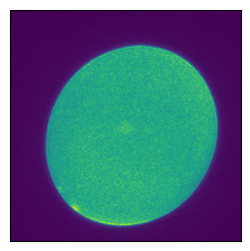

In [23]:
ind_vac = (0,0)
imdata = dpc4d.io.load_single_mrc_frame(filepath_input,ind_vac,scan_shape=scan_shape)

plt.figure(figsize=(3,3))
plt.imshow(imdata)
plt.xticks([])
plt.yticks([])

### Compute CoM

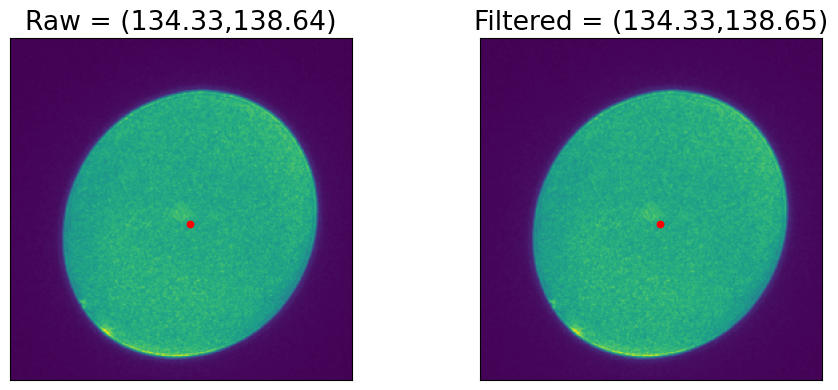

In [24]:
# Filter the disk image
k_thresh = 50
filt_sigma = 0

imfilt = np.zeros(imdata.shape)
imfilt[:] = imdata[:]
if filt_sigma>0:
    imfilt = gaussian_filter(imdata,filt_sigma)
imfilt = imfilt*(imfilt>k_thresh)

# Compute CoM for original and filtered image
CoM_0 = dpc4d.process.compute_CoM(imdata,Qx,Qy)
CoM_0_disp = ["{:.2f}".format(val) for val in CoM_0]
CoM_0_filt = dpc4d.process.compute_CoM(imfilt,Qx,Qy)
CoM_0_filt_disp = ["{:.2f}".format(val) for val in CoM_0_filt]

imlist = [imdata,imfilt]
CoM_list = [CoM_0,CoM_0_filt]
CoM_disp_list = [CoM_0_disp,CoM_0_filt_disp]
title_list = ['Raw','Filtered']

plt.figure(figsize=(10,4))
for i_plot in range(2):
    CoM = CoM_list[i_plot]
    CoM_disp = CoM_disp_list[i_plot]
    
    plt.subplot(1,2,i_plot+1)
    plt.imshow(imlist[i_plot])
    
    plt.plot(CoM[0],CoM[1],'r.')
    plt.xticks([])
    plt.yticks([])
    plt.title(title_list[i_plot]+' = ' + '(' + CoM_disp[0] + ',' + CoM_disp[1] + ')' )

plt.tight_layout()

### Fit ellipse to the edge

Text(0.5, 1.0, 'Initial guess ellipse')

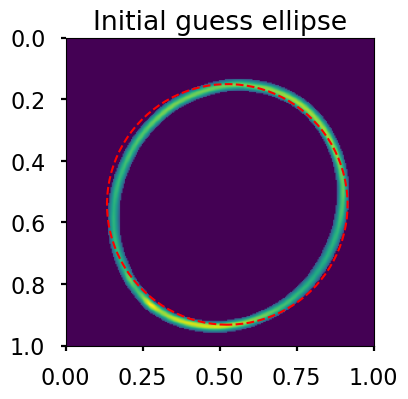

In [25]:
# Provide inital guess parameters
R_guess_px = 100

# Edge filtering
filt_sigma = 3
_,_,Gmag_ref,_ = dpc4d.process.compute_gradient_maps(imdata,thresh=0.25,filt_sigma=filt_sigma)

# Generate remaining parameters
R_guess = R_guess_px/Q_Nx
A,B,C = dpc4d.process.convert_ellipse_params_r(R_guess,R_guess,0) # initial guess
p0 = [np.max(Gmag_ref),
     filt_sigma/Q_Nx,
     np.min(Gmag_ref),
     CoM_0_filt[0]/Q_Nx,
     CoM_0_filt[1]/Q_Ny,
     A,B,C]

x_ell,y_ell = dpc4d.visualize.draw_ellipse(p0)
plt.figure(figsize=(4,4))
plt.imshow(Gmag_ref,extent=[0,1,1,0])
plt.plot(x_ell,y_ell,'r--',lw=1.5)
plt.title('Initial guess ellipse')

In [26]:
# Perform fit
def residual(p,data,X,Y):
    return np.mean((data-dpc4d.process.gaussian_ring(p,X,Y))**2)

out = minimize(residual,p0,args=(Gmag_ref,Qx/Q_Nx,Qy/Q_Ny))
pfit = out.x

Text(0.5, 1.0, 'Fit ellipse')

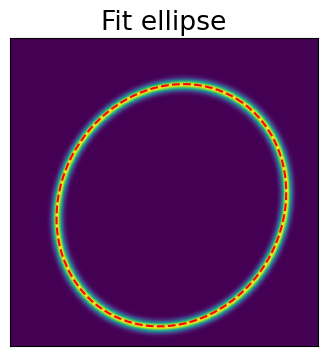

In [27]:
# Show fit ellipse
x_ell,y_ell = dpc4d.visualize.draw_ellipse(pfit)
plt.figure(figsize=(4,4))
plt.imshow(dpc4d.process.gaussian_ring(pfit,Qx/Q_Nx,Qy/Q_Ny),extent=[0,1,1,0])
plt.plot(x_ell,y_ell,'r--',lw=1.5)
plt.xticks([])
plt.yticks([])
plt.title('Fit ellipse')

In [28]:
a,b,theta = dpc4d.process.convert_ellipse_params(pfit[5],pfit[6],pfit[7])
print(f'Major and minor radii (px): [{float(a*Q_Nx):.2f},{float(b*Q_Nx):.2f}]')
R0_mean = np.mean([a,b])*Q_Nx
print(f'Mean radius (px): {R0_mean:.2f}')

Major and minor radii (px): [103.75,92.16]
Mean radius (px): 97.95


### Generate elliptical kernel for "elliptical Hough transform"

Text(0.5, 1.0, 'Elliptical kernel')

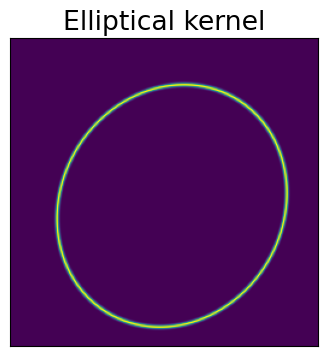

In [29]:
k_sigma = 1 #px (width of elliptical ring kernel)

p2 = np.zeros(pfit.shape)
p2[:] = pfit[:]
p2[1] = k_sigma/Q_Nx # Set 
K_ell = dpc4d.process.gaussian_ring(p2,Qx/Q_Nx,Qy/Q_Ny)

plt.figure(figsize=(4,4))
plt.imshow(K_ell)
plt.xticks([])
plt.yticks([])
plt.title('Elliptical kernel')

## Test shift finding methods on selected disks

### Test single disk

Shifts (px):  [-0. -4.]


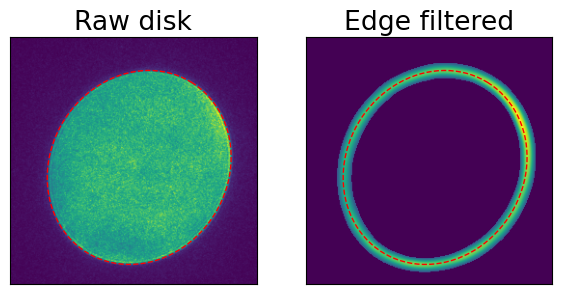

In [30]:
# Test matching on a single test disk

# Load test disk
ind_test = (55,44)
imdata = dpc4d.io.load_single_mrc_frame(filepath_input,ind_test,scan_shape=scan_shape)

filt_sigma = 5
thresh = 0.25

p_ell = np.zeros(pfit.shape)

shifts,Gmag = dpc4d.process.compute_shift_ecc(imdata.astype('double'),Qx,Qy,
                                           K_ell,thresh=thresh,filt_sigma=filt_sigma)
print('Shifts (px): ', shifts)

x_ell,y_ell = dpc4d.visualize.draw_shifted_ellipse((shifts[1],shifts[0]),pfit,Q_Nx,Q_Ny)

imlist = [imdata,Gmag]
title_list = ['Raw disk','Edge filtered']

plt.figure(figsize=(7,4))
for i_plot in range(2): 
    plt.subplot(1,2,i_plot+1)
    plt.imshow(imlist[i_plot],extent=[0,1,1,0])
    plt.plot(x_ell,y_ell,'r--',lw=1.0)
    plt.xticks([])
    plt.yticks([])
    plt.title(title_list[i_plot])

### Test selected set

Shifts (px):  [[ -0.03   0.03]
 [ -1.43  -4.74]
 [  3.46 -27.41]
 [  4.09 -12.29]
 [  4.7  -18.35]]


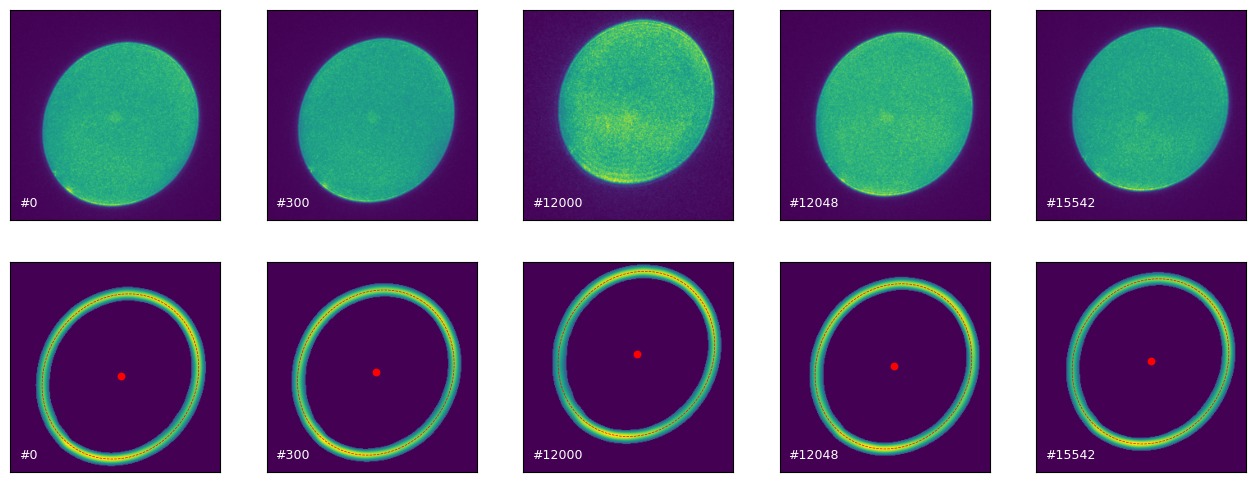

In [31]:
# Load selected disks into memory and show them
inds_select = [0,300, 12000,12048,15542]

im_list_select = dpc4d.io.load_selected_frames_mrc(filepath_input,inds_select)
n_plots = len(inds_select)

# preprocess and perform computation on the array
imfilt_list = []
CoM_arr = np.zeros((n_plots,2))
for i_plot in range(n_plots):
    imdata = im_list_select[i_plot]
    CoM_shift,Gmag = dpc4d.process.compute_shift_ecc(imdata,Qx,Qy,K_ell)
    imfilt_list.append(Gmag)
    CoM_arr[i_plot,:] = CoM_shift + CoM_0_filt

shifts_arr = CoM_arr - CoM_0_filt
print('Shifts (px): ',shifts_arr)

plt.figure(figsize=(16,6))
for i_plot in range(n_plots):
    plt.subplot(2,n_plots,i_plot+1)
    plt.imshow(im_list_select[i_plot])
    plt.text(10, 240, f'#{inds_select[i_plot]}', fontsize=9, c='white')
    plt.xticks([])
    plt.yticks([])
    
    plt.subplot(2,n_plots,n_plots+i_plot+1)
    plt.imshow(imfilt_list[i_plot])
    plt.plot(CoM_arr[i_plot,0],CoM_arr[i_plot,1],'r.')
    plt.text(10, 240, f'#{inds_select[i_plot]}', fontsize=9, c='white')
    plt.xticks([])
    plt.yticks([])
    shift_ell = (shifts_arr[i_plot,1],shifts_arr[i_plot,0])
    x_ell,y_ell = dpc4d.visualize.draw_shifted_ellipse(shift_ell,pfit,Q_Nx,Q_Ny)
    plt.plot(x_ell*Q_Nx,y_ell*Q_Ny,'r--',lw=0.5)

## Reconstruct a single line

In [40]:
# Select scan line to test
ind_line = 64
scan_dir='row'

# Load scan line
data_array = dpc4d.io.load_scan_line(filepath_input,dataset_shape_4D,ind_line,scan_dir=scan_dir)

In [41]:
# Compute shifts
shift_array,im_proc_array = dpc4d.process.compute_shift_array_ecc(data_array,Qx,Qy,K_ell)
shift_array -= shift_array[0]

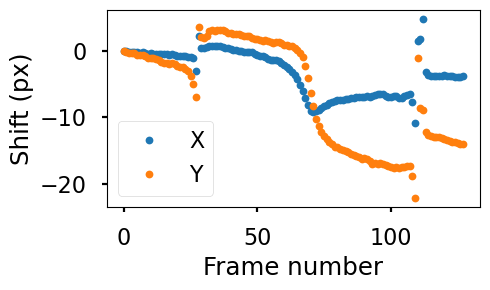

In [42]:
# Plot the resulting shifts
plt.figure(figsize=(5,3))
plt.plot(shift_array[:,0],'.')
plt.plot(shift_array[:,1],'.')
plt.xlabel('Frame number')
plt.ylabel('Shift (px)')
plt.legend(['X','Y'])
plt.tight_layout()

### Plot phase gradients (optional)

In [43]:
# Input required parameters:
nm_per_px_x = 40.04 #nm
nm_per_px_y = 40.04 #nm
lamb_elec = 0.00251 #nm
alpha = 200 #urad
rot_theta = 95*(np.pi/180) # rad

urad_per_px = alpha/R0_mean

shift_array_rot = dpc4d.process.rotate_coord_list(shift_array,rot_theta)
defl = shift_array_rot*urad_per_px #urad

phase_grad = dpc4d.process.convert_defl_to_phase_grad(lamb_elec,defl*1e-6)

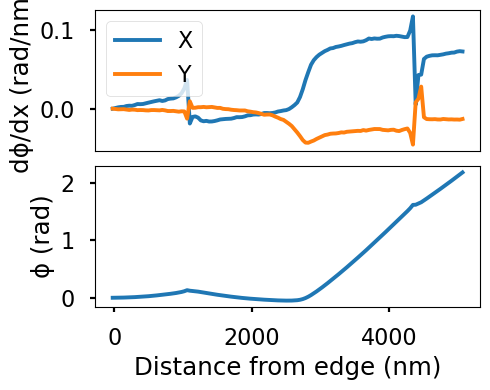

In [44]:
x = np.arange(R_Nx)*nm_per_px_x
x0 = 20

plt.figure(figsize=(5,4))
plt.subplot(2,1,1)
plt.plot(x-x0,phase_grad)
plt.xticks([])
plt.ylabel('dϕ/dx (rad/nm)')
plt.legend(('X','Y'))

plt.subplot(2,1,2)
plt.plot(x-x0,np.cumsum(phase_grad[:,0],axis=0)*0.5)
plt.xlabel('Distance from edge (nm)')
plt.ylabel('ϕ (rad)')

plt.tight_layout()

# plt.savefig('output/ECC'+sample_shape+'_'+scan_dir+str(ind_line)+'_phase_grad.png',dpi=400)

### Generate movie (optional)

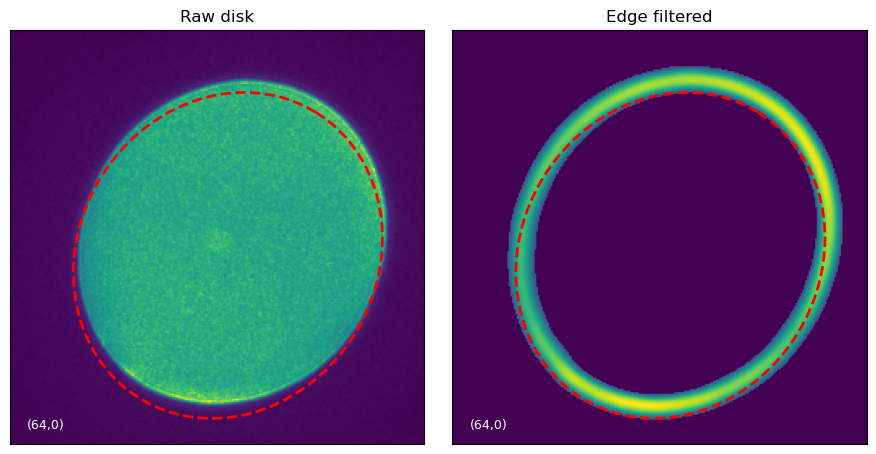

In [45]:
# Preview first movie frame
ind_test = 0
mov_norm = False # Normalize each frame to same mean intensity
mov_gamma = 1 # Gamma correction of each frame

%matplotlib inline
fig,axs,ims,ells,textlabels = dpc4d.visualize.setup_scan_shifts_movie(data_array,im_proc_array,shift_array,p_ell=pfit,
                                                         index=ind_line,ind_test=ind_test,norm=mov_norm,gamma=mov_gamma)
# plt.savefig(f'output/ECC_first_movie_frame_{scan_dir}{ind_line}.png')

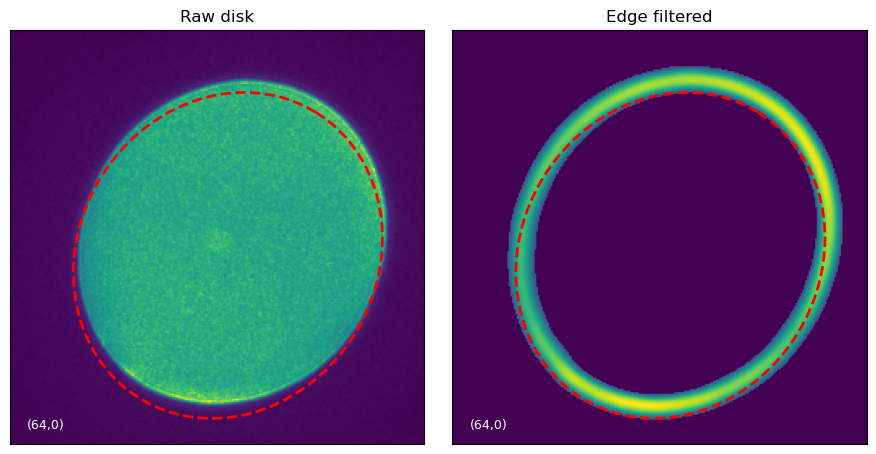

In [46]:
# Generate movie
fname = 'output/ECC'+sample_shape+'_'+scan_dir + str(ind_line) + '_scan_shifts.mp4'
dpc4d.visualize.generate_scan_shifts_movie(data_array,im_proc_array,shift_array,fname,index=ind_line,
                           fps=20,norm=mov_norm,gamma=mov_gamma,dpi=400,show_ellipse=True,p_ell=pfit)

## Compute shifts on the full image

In [47]:
# Load in the data line by line

shift_map = np.zeros((R_Ny,R_Nx,2))
for ind_line in range(R_Ny):
    print('Processing line '+str(ind_line)+'/'+str(R_Ny)+'...')
    data_array = dpc4d.io.load_scan_line(filepath_input,dataset_shape_4D,ind_line,scan_dir=scan_dir)
    # Compute shifts
    shift_array,_ = dpc4d.process.compute_shift_array_ecc(data_array,Qx,Qy,K_ell)
    shift_map[ind_line,:,:] = shift_array[:,:]

Processing line 0/128...
Processing line 1/128...
Processing line 2/128...
Processing line 3/128...
Processing line 4/128...
Processing line 5/128...
Processing line 6/128...
Processing line 7/128...
Processing line 8/128...
Processing line 9/128...
Processing line 10/128...
Processing line 11/128...
Processing line 12/128...
Processing line 13/128...
Processing line 14/128...
Processing line 15/128...
Processing line 16/128...
Processing line 17/128...
Processing line 18/128...
Processing line 19/128...
Processing line 20/128...
Processing line 21/128...
Processing line 22/128...
Processing line 23/128...
Processing line 24/128...
Processing line 25/128...
Processing line 26/128...
Processing line 27/128...
Processing line 28/128...
Processing line 29/128...
Processing line 30/128...
Processing line 31/128...
Processing line 32/128...
Processing line 33/128...
Processing line 34/128...
Processing line 35/128...
Processing line 36/128...
Processing line 37/128...
Processing line 38/128

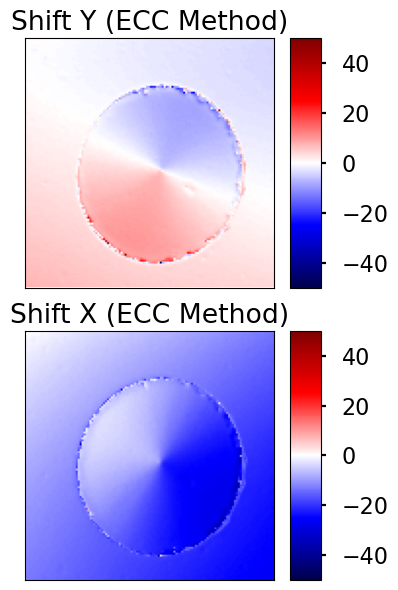

In [48]:
# Save the result
np.save('output/ECC'+sample_shape+'_shift_map.npy',shift_map)

# Plot & save shifts
dpc4d.visualize.plot_diff_maps([shift_map[:,:,0],shift_map[:,:,1]],['Shift Y (ECC Method)','Shift X (ECC Method)'],4,6,clim=(-50,50))

plt.savefig('output/ECC' + sample_shape + '_shift_visualization.png')